### 1.이미지 크기맞추기
### 2. 컬러사진 그대로 사용하기 

In [1]:
import numpy as np 
from PIL import Image
import glob

---
### 전체 사진중 최대 해상도 찾기

In [2]:
# Names
dirNames = ['Aiden','Andrew','Cathy']

In [3]:
widthRatio = []
heightRatio = []

for name in dirNames:
    for file in sorted(glob.glob(f"../Data/Face/{name}/*.jpg")):
        img = np.array(Image.open(file), dtype=np.int32)
        widthRatio.append(img.shape[1])
        heightRatio.append(img.shape[0])

In [4]:
print("너비 최대 해상도:", np.max(widthRatio))
print("높이 최대 해상도:", np.max(heightRatio))

너비 최대 해상도: 299
높이 최대 해상도: 381


> 해상도 크기 결정 : 400 * 300 


In [9]:
# 전체 사진을 400 * 300 의 고정크리고 맞추기

for name in dirNames:
    fileCount = 0
    for file in sorted(glob.glob(f"../Data/Face/{name}/*.jpg")):
        img = Image.open(file).convert('RGB')
        imgArray = np.array(img)

        imgDummy = np.zeros((400, 300, 3), dtype=np.uint8)
        rowNum = (400 - imgArray.shape[0]) / 2
        colNum = (300 - imgArray.shape[1]) / 2

        k = 0
        for i in range(int(rowNum), int(rowNum) + imgArray.shape[0]):
            l = 0
            for j in range(int(colNum), int(colNum) + imgArray.shape[1]):
                imgDummy[i, j] = imgArray[k, l]
                l += 1
            k += 1

        img2 = Image.fromarray(imgDummy, 'RGB')
        img2.save(f"../Data/FaceColor/{name}/image_{fileCount:02}.jpg", "JPEG")
        fileCount += 1

#### 회전 추가

In [10]:
import os

# Face 폴더 안에 있는 사람 이름 폴더 목록 가져오기
dirNames = os.listdir("../Data/Face")

# 혹시 파일이 섞여 있으면 폴더만 남기기
dirNames = [
    name for name in dirNames
    if os.path.isdir(f"../Data/Face/{name}")
]

print(dirNames)


['Aiden', 'Andrew', 'Cathy']


In [11]:
import os

# 전체 사진을 400 * 300 고정 크기로 검은색 배경에 맞추고
# 회전 + 좌우반전 이미지까지 추가 저장하기

for name in dirNames:
    saveDir = f"../Data/FaceColor/{name}"
    os.makedirs(saveDir, exist_ok=True)

    # 기존 파일이 있으면 덮어쓰지 않고 다음 번호부터 저장
    fileCount = len(glob.glob(f"{saveDir}/image_*.jpg"))

    for file in sorted(glob.glob(f"../Data/Face/{name}/*.jpg")):
        img = Image.open(file).convert('RGB')

        imgList = []

        # 원본 이미지 추가
        imgList.append(img)

        # 회전 이미지 + 좌우반전 이미지 추가
        for angle in range(15, 15, 1):
            imgRotated = img.rotate(angle)
            imgList.append(imgRotated)

            imgFlipped = imgRotated.transpose(Image.FLIP_LEFT_RIGHT)
            imgList.append(imgFlipped)

        # 원본, 회전, 반전 이미지를 모두 400x300으로 맞춰 저장
        for imgData in imgList:
            imgArray = np.array(imgData)

            imgDummy = np.zeros((400, 300, 3), dtype=np.uint8)

            rowNum = (400 - imgArray.shape[0]) / 2
            colNum = (300 - imgArray.shape[1]) / 2

            k = 0
            for i in range(int(rowNum), int(rowNum) + imgArray.shape[0]):
                l = 0
                for j in range(int(colNum), int(colNum) + imgArray.shape[1]):
                    imgDummy[i, j] = imgArray[k, l]
                    l += 1
                k += 1

            img2 = Image.fromarray(imgDummy, 'RGB')
            savePath = f"{saveDir}/image_{fileCount:03}.jpg"

            while os.path.exists(savePath):
                fileCount += 1
                savePath = f"{saveDir}/image_{fileCount:03}.jpg"

            img2.save(savePath, "JPEG")
            fileCount += 1


#### 사진들을 numpy배열을 이용하여 Training Data 만들기

In [12]:
number_of_data = sum(len(glob.glob(f'../Data/FaceColor/{name}/*.jpg')) for name in dirNames)
img_width_size = 300
img_height_size = 400
img_color = 3 # 이미지 컬러

In [13]:
train = np.zeros(
        number_of_data * img_width_size * img_height_size * img_color,
        dtype=np.int32
).reshape(number_of_data, img_height_size, img_width_size , img_color)

In [14]:
i = 0
for name in dirNames:
    for file in sorted(glob.glob(f'../Data/FaceColor/{name}/*.jpg')):
        img = np.array(Image.open(file),dtype=np.int32)
        train[i,:,:] = img
        i += 1

In [15]:
train.shape

(108, 400, 300, 3)

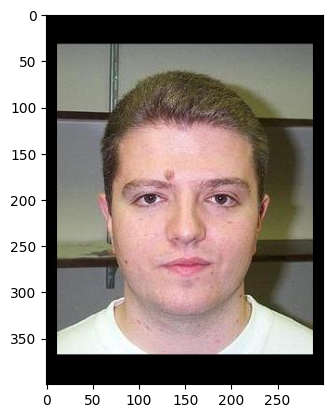

In [16]:
# 이미지 확인하기
import matplotlib.pyplot as plt
plt.imshow(train[0].reshape(400, 300, 3))
plt.show()

In [17]:
dirNames

['Aiden', 'Andrew', 'Cathy']

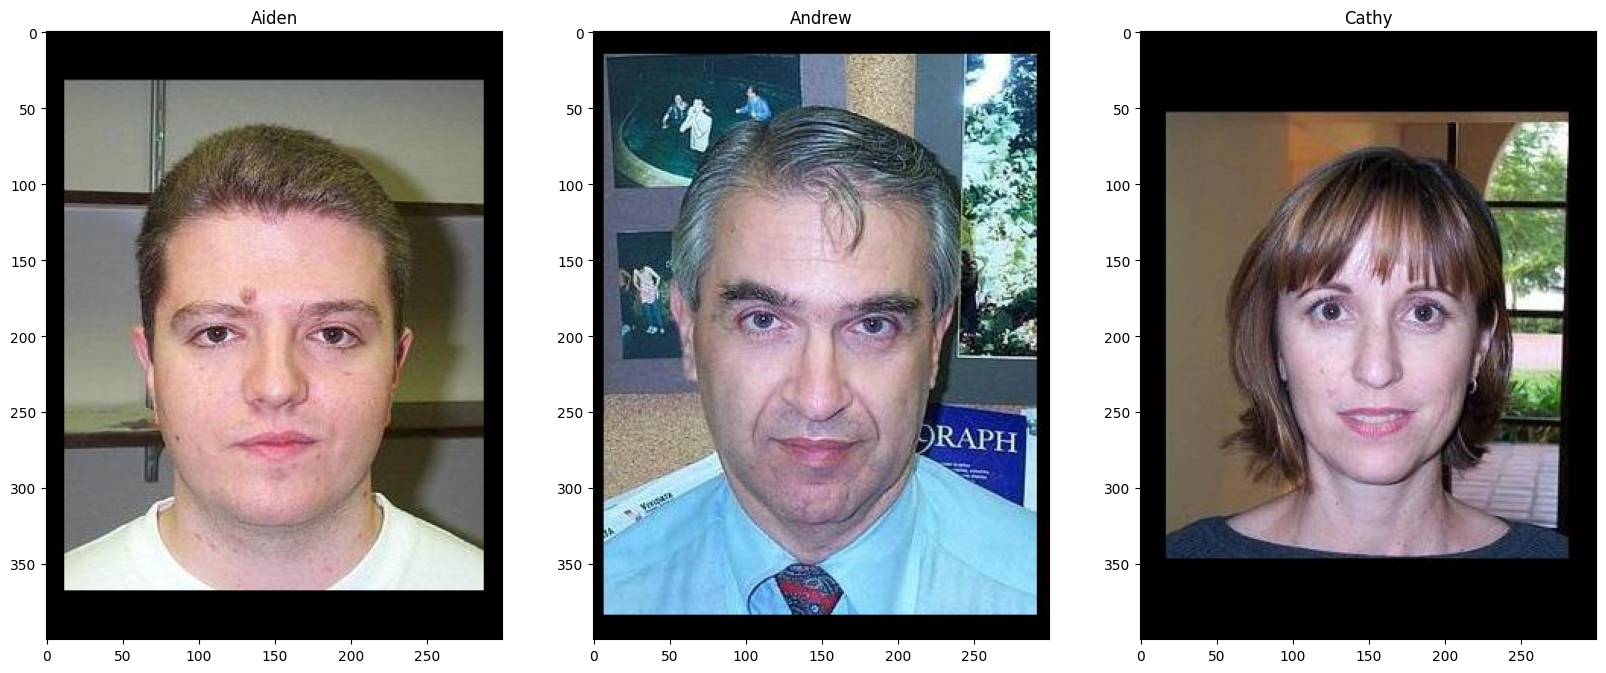

In [18]:
plt.figure(figsize=(20,20))
orderNo = []
start = 0

for name in dirNames:
    orderNo.append(start)
    start += len(glob.glob(f'../Data/FaceColor/{name}/*.jpg'))

for i in range(1,len(dirNames)+1):
    plt.subplot(1,len(dirNames), i)
    plt.imshow(train[orderNo[i-1]].reshape(400,300,3))
    plt.title(dirNames[i-1])

### target data 만들기

In [19]:
target_list = []
for idx, name in enumerate(dirNames):
    image_count = len(glob.glob(f'../Data/FaceColor/{name}/*.jpg'))
    target_list.extend([idx] * image_count)

target = np.array(target_list, dtype=np.int64)

In [20]:
target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### 정규화하기

In [21]:
train_scaled = train.reshape(-1, 400,300, 3) / 255.0
train[2:]

array([[[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        ...,

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]]],


       [[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[0, 0, 0],
         [0,

---
#### PyTorch CNN으로 학습하기

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

In [23]:
classes = dirNames
class_to_idx = {name: idx for idx, name in enumerate(classes)}

images = torch.tensor(train_scaled, dtype=torch.float32)
targets = torch.tensor(target, dtype=torch.long)

image_paths = []
for name in dirNames:
    image_paths.extend(sorted(glob.glob(f'../Data/FaceColor/{name}/*.jpg')))

print('classes :', classes)
print('class_to_idx :', class_to_idx)
print(images.shape)
print(targets.shape)

classes : ['Aiden', 'Andrew', 'Cathy']
class_to_idx : {'Aiden': 0, 'Andrew': 1, 'Cathy': 2}
torch.Size([108, 400, 300, 3])
torch.Size([108])


In [24]:
# Train data를 훈련 데이터와 검증 데이터로 나누기
train_paths, test_paths, train_input, test_input, train_target, test_target = train_test_split(
    image_paths,
    images,
    targets,
    test_size=0.2,
    random_state=42,
    stratify=targets.numpy()
)

train_paths, val_paths, train_input, val_input, train_target, val_target = train_test_split(
    train_paths,
    train_input,
    train_target,
    test_size=0.2,
    random_state=42,
    stratify=train_target.numpy()
)

In [25]:
# Dimension
print(train_input.shape, train_target.shape)
print(val_input.shape, val_target.shape)
print(test_input.shape, test_target.shape)

torch.Size([68, 400, 300, 3]) torch.Size([68])
torch.Size([18, 400, 300, 3]) torch.Size([18])
torch.Size([22, 400, 300, 3]) torch.Size([22])


----
#### CNN 신경망 만들기

In [26]:
# DataSet과 DataLoader 생성

batch_size = 8

train_dataset = TensorDataset(train_input, train_target)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(val_input, val_target)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

test_dataset = TensorDataset(test_input, test_target)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

#### 모델 정의

In [27]:
class CNNModel(nn.Module):

    def __init__(self, num_classes):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.relu3(x)
        x = self.pool3(x)

        x = self.adaptive_pool(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu4(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x


In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
print(device)

model = CNNModel(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

cpu


In [29]:
# 모델, 손실함수, 옵티마이져
model.to(device)

CNNModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=3, bias=True)
)

----
#### 모델 훈련

In [30]:
# 학습 함수

def train(model, train_loader, criterion, optimizer, device):
    model.train()                           # Dropout, BatchNorm 등의 레이어가 훈련 모드로 동작하도록 설정
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        # 입력 데이처의 차원 순서 변경 (B, H, W, C) -> (B, C, H, W)
        # PyTorch의 컨볼루션 레이어는 입력 텐서의 형태가 (배치 크기, 채널, 높이, 너비)여야 합니다.
        # 현재 데이터가 (배치 크기, 높이, 너비, 채널) 형태이므로, permute 함수를 사용하여 차원 순서를 변경했습니다.
        inputs = inputs.permute(0, 3, 1, 2)
        optimizer.zero_grad()               # 이전 반복에서 계산된 그래디언트를 초기화
        outputs = model(inputs)             # 내부적으로 model.forward(input_data) 호출, 모델에 입력을 전달하여 예측값을 얻음
        loss = criterion(outputs, targets)  # 모델의 예측값과 실제 타겟 간의 손실을 계산
        loss.backward()              # 손실에 대한 그래디언트를 계산하고 역전파
        optimizer.step()             # 계산된 그래디언트를 사용하여 모델의 파라미터를 업데이트

    return loss.item()

In [31]:
# # 학습 함수
# def train(model, train_loader, criterion, optimizer, device):
#     model.train()
#     total_loss = 0

#     for inputs, targets in train_loader:
#         inputs, targets = inputs.to(device), targets.to(device)
#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, targets)
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()

#     return total_loss / len(train_loader)

In [32]:
# 평가 함수
def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            inputs = inputs.permute(0, 3, 1, 2)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    return total_loss / len(data_loader), correct / total

In [33]:
# 훈련하기

num_epochs = 50
train_loss_scores = []
val_loss_scores = []

for epoch in range(num_epochs):
    train_loss = train(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)
    train_loss_scores.append(train_loss)
    val_loss_scores.append(val_loss)
    print(f'Epoch [{epoch + 1:>3} / {num_epochs}], Loss : {train_loss:.4f}, Val_loss : {val_loss:.4f}, Val_accuracy : {val_accuracy:.4f}')

Epoch [  1 / 50], Loss : 1.0549, Val_loss : 1.0721, Val_accuracy : 0.3889
Epoch [  2 / 50], Loss : 0.8887, Val_loss : 0.8703, Val_accuracy : 0.6667
Epoch [  3 / 50], Loss : 0.7642, Val_loss : 0.7779, Val_accuracy : 0.7222
Epoch [  4 / 50], Loss : 0.2777, Val_loss : 0.3772, Val_accuracy : 0.7778
Epoch [  5 / 50], Loss : 0.1056, Val_loss : 0.6833, Val_accuracy : 0.8889
Epoch [  6 / 50], Loss : 0.4572, Val_loss : 0.1831, Val_accuracy : 0.8333
Epoch [  7 / 50], Loss : 0.1719, Val_loss : 0.0680, Val_accuracy : 1.0000
Epoch [  8 / 50], Loss : 0.0446, Val_loss : 0.2406, Val_accuracy : 0.7222
Epoch [  9 / 50], Loss : 0.0249, Val_loss : 0.4549, Val_accuracy : 0.7222
Epoch [ 10 / 50], Loss : 0.0091, Val_loss : 0.1661, Val_accuracy : 0.8889
Epoch [ 11 / 50], Loss : 0.0017, Val_loss : 0.6210, Val_accuracy : 0.7222
Epoch [ 12 / 50], Loss : 0.0582, Val_loss : 0.1794, Val_accuracy : 0.8889
Epoch [ 13 / 50], Loss : 0.0002, Val_loss : 0.1906, Val_accuracy : 0.7778
Epoch [ 14 / 50], Loss : 0.0231, Val_l

In [34]:
# 훈련 평가
train_loss, train_accuracy = evaluate(model, train_loader, criterion, device)
print(f'Train Loss : {train_loss:.4f}, Train Accuracy : {train_accuracy:.4f}')

# 검증 평가
val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)
print(f'Val Loss : {val_loss:.4f}, Val Accuracy : {val_accuracy:.4f}')

# 테스트 평가
test_loss, test_accuracy = evaluate(model, test_loader, criterion, device)
print(f'Test Loss : {test_loss:.4f}, Test Accuracy : {test_accuracy:.4f}')

Train Loss : 0.0000, Train Accuracy : 1.0000
Val Loss : 0.0010, Val Accuracy : 1.0000
Test Loss : 0.0001, Test Accuracy : 1.0000


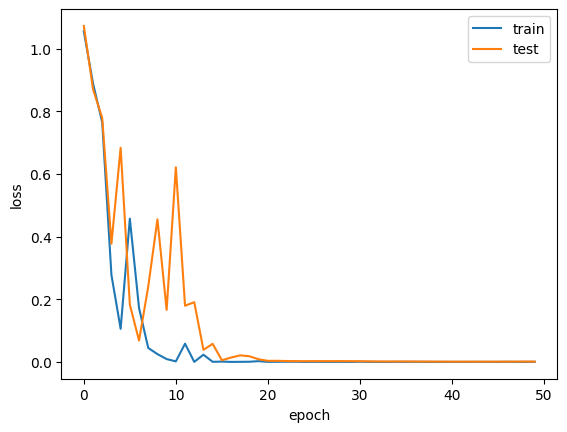

In [35]:
# 시각화 해보기
plt.plot(train_loss_scores)
plt.plot(val_loss_scores)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','test'])
plt.show()

----
#### 학습한 모델 저장하기

In [36]:
model_path = '../Data/cnn_face_color.pth'
torch.save(model, model_path)
print(model_path)

../Data/cnn_face_color.pth


In [37]:
model1 = torch.load(model_path, weights_only=False, map_location=device)
model1.eval()

CNNModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=3, bias=True)
)

----
#### Image를 불러서 예측

../Data/FaceColor/Andrew/image_021.jpg


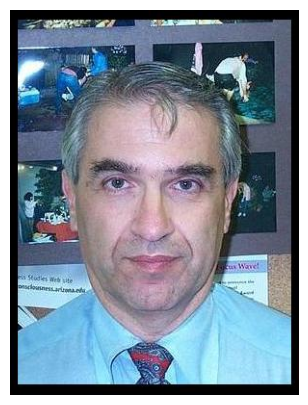

In [38]:
sample_image_path = test_paths[0]
print(sample_image_path)

img = Image.open(sample_image_path).convert('RGB').resize((img_width_size, img_height_size))
plt.figure(figsize=(4, 5))
plt.imshow(img)
plt.axis('off')
plt.show()

In [39]:
img = np.array(img, dtype=np.float32) / 255.0
img = torch.tensor(img).permute(2, 0, 1)
print(img.shape)

torch.Size([3, 400, 300])


In [40]:
# 단일 데이터 예측 함수
def predictOne(model, image, device, classes):
    model.eval()
    with torch.no_grad():
        image = image.unsqueeze(0).to(device)
        outputs = model(image)
        _, predicted = torch.max(outputs, 1)
        predicted_class = classes[predicted.item()]
    return predicted_class

In [41]:
predictOne(model1, img, device, classes)

'Andrew'